# Decision Tree Classifier — An Illustrated Tour

> A Decision Tree asks a sequence of yes/no questions about the features, splitting data into increasingly pure groups until it reaches a prediction.

---

**What we cover:**
- How trees split data — impurity measures
- Growing a tree step-by-step
- Depth control — underfitting vs overfitting
- Decision boundaries — the staircase pattern
- Feature importance from split gains
- Confusion matrix and metrics

## The picture — axis-aligned splits carve the input into rectangles

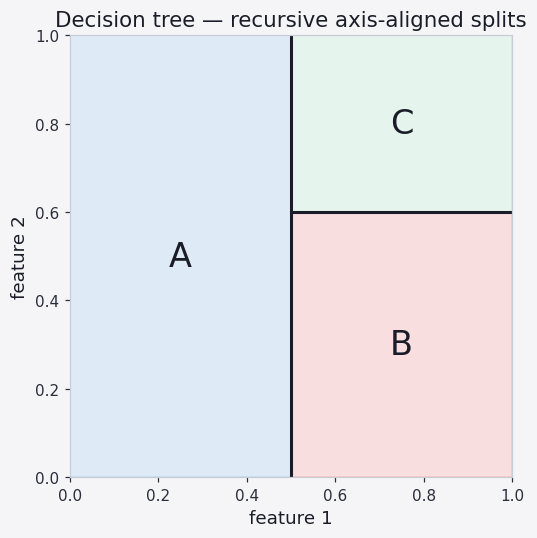

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, ax = plt.subplots(figsize=(7, 5))
# Three regions in a [0,1]x[0,1] box
ax.add_patch(Rectangle((0,0),0.5,1, color=P[0], alpha=0.20))
ax.add_patch(Rectangle((0.5,0),0.5,0.6, color=P[1], alpha=0.20))
ax.add_patch(Rectangle((0.5,0.6),0.5,0.4, color=P[3], alpha=0.20))
ax.axvline(0.5, color='#1a1d27', lw=2); ax.plot([0.5,1],[0.6,0.6], color='#1a1d27', lw=2)
ax.text(0.25,0.5,'A', ha='center', va='center', fontsize=22, color='#1a1d27')
ax.text(0.75,0.3,'B', ha='center', va='center', fontsize=22, color='#1a1d27')
ax.text(0.75,0.8,'C', ha='center', va='center', fontsize=22, color='#1a1d27')
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
ax.set_xlabel('feature 1'); ax.set_ylabel('feature 2')
ax.set_title('Decision tree — recursive axis-aligned splits')
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              accuracy_score, precision_score, recall_score, f1_score)

# ── Presentation style ─────────────────────────────────────────────────────
PLT_STYLE = {
    'figure.facecolor':'#f5f5f7', 'axes.facecolor':'#ffffff',
    'axes.edgecolor':'#c8ccd4',   'axes.labelcolor':'#1a1d27',
    'axes.titlecolor':'#1a1d27',  'xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a',      'grid.color':'#e0e3ea',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'text.color':'#1a1d27',       'font.family': 'DejaVu Sans',
    'axes.titlesize': 17,          'axes.labelsize': 13,
    'xtick.labelsize': 11,         'ytick.labelsize': 11,
    'legend.fontsize': 11,         'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4', 'figure.dpi': 120,
}
plt.rcParams.update(PLT_STYLE)

C0 = '#5b9bd5'; C1 = '#e05c5c'; CB = '#f4b942'
CM = '#7ecba1'; CH = '#56b6c2'; CP = '#c678dd'

# ── 2-D dataset (moons — non-linear) ──────────────────────────────────────
np.random.seed(0)
X2, y2 = make_moons(n_samples=200, noise=0.25, random_state=0)

# ── High-dim dataset for metrics ───────────────────────────────────────────
X, y = make_classification(n_samples=200, n_features=20,
                            n_informative=10, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

print('2-D dataset: moons (200 samples, non-linear)')
print('Full dataset: 1000 samples, 20 features')

2-D dataset: moons (200 samples, non-linear)
Full dataset: 1000 samples, 20 features


---
## How Trees Split — Impurity Measures

At each node, a tree chooses the **feature and threshold** that most reduces impurity.

**Gini impurity:** $G = 1 - \sum_k p_k^2$ — 0 when the node is pure, 0.5 when perfectly mixed.

**Entropy:** $H = -\sum_k p_k \log_2 p_k$ — 0 when pure, 1 when perfectly mixed.

Both measures penalise mixed nodes and reward pure ones.

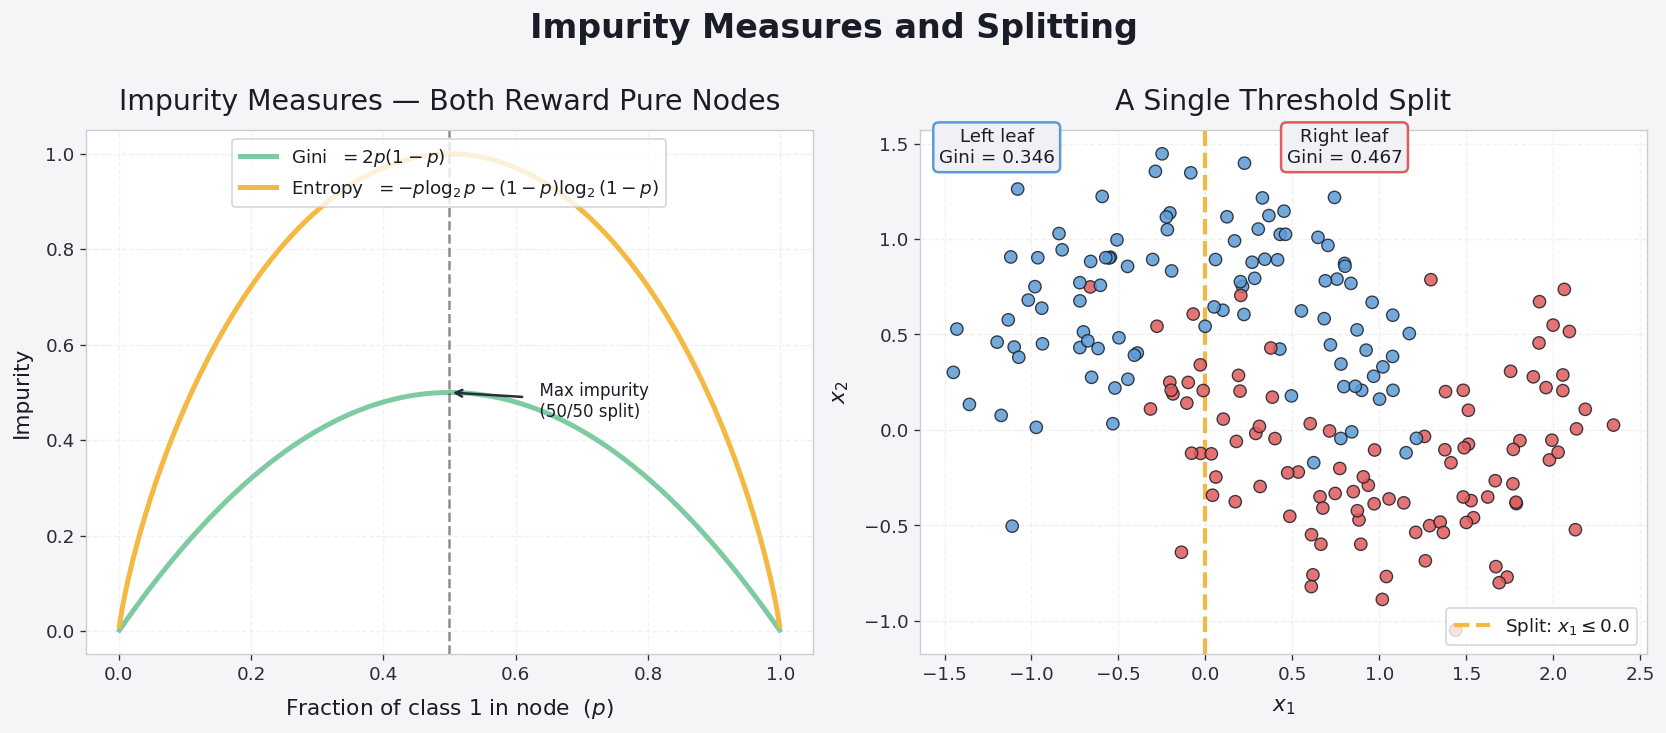

In [3]:
p = np.linspace(0.001, 0.999, 300)  # p = fraction of class 1
gini    = 2 * p * (1 - p)
entropy = -(p * np.log2(p) + (1-p) * np.log2(1-p))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: impurity curves
ax = axes[0]
ax.plot(p, gini,    color=CM, lw=3, label='Gini  $= 2p(1-p)$')
ax.plot(p, entropy, color=CB, lw=3, label='Entropy  $= -p\\log_2 p - (1-p)\\log_2(1-p)$')
ax.axvline(0.5, color='#1a1d27', ls='--', lw=1.5, alpha=0.5)
ax.annotate('  Max impurity\n  (50/50 split)',
            xy=(0.5, gini[150]), xytext=(0.62, 0.45),
            fontsize=10, color='#1a1d27',
            arrowprops=dict(arrowstyle='->', color='#2a2e3a', lw=1.5))
ax.set_xlabel('Fraction of class 1 in node  ($p$)', labelpad=8)
ax.set_ylabel('Impurity', labelpad=8)
ax.set_title('Impurity Measures — Both Reward Pure Nodes', pad=12)
ax.legend(loc='upper center'); ax.grid(True)

# Right: visualise a single split
ax = axes[1]
ax.scatter(X2[:, 0], X2[:, 1],
           c=[C1 if yi else C0 for yi in y2], s=55,
           edgecolors='#1a1d27', lw=0.8, alpha=0.85, zorder=4)

# Draw a simple threshold split
split_val = 0.0
ax.axvline(split_val, color=CB, lw=2.5, ls='--', label=f'Split: $x_1 \\leq {split_val}$')

left_mask  = X2[:,0] <= split_val
right_mask = ~left_mask
gini_left  = 2 * y2[left_mask].mean() * (1 - y2[left_mask].mean())
gini_right = 2 * y2[right_mask].mean() * (1 - y2[right_mask].mean())

ax.text(split_val - 1.2, 1.4, f'Left leaf\nGini = {gini_left:.3f}',
        ha='center', fontsize=11,
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec=C0, lw=1.5))
ax.text(split_val + 0.8, 1.4, f'Right leaf\nGini = {gini_right:.3f}',
        ha='center', fontsize=11,
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec=C1, lw=1.5))

ax.set_xlabel('$x_1$', labelpad=8); ax.set_ylabel('$x_2$', labelpad=8)
ax.set_title('A Single Threshold Split', pad=12)
ax.legend(loc='lower right'); ax.grid(True)

fig.suptitle('Impurity Measures and Splitting', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Depth Control — Underfitting vs Overfitting

Tree **depth** is the key hyperparameter:
- Too shallow → regions too large → **underfits** (high bias)
- Too deep → each leaf has 1 sample → **memorises noise** (high variance)

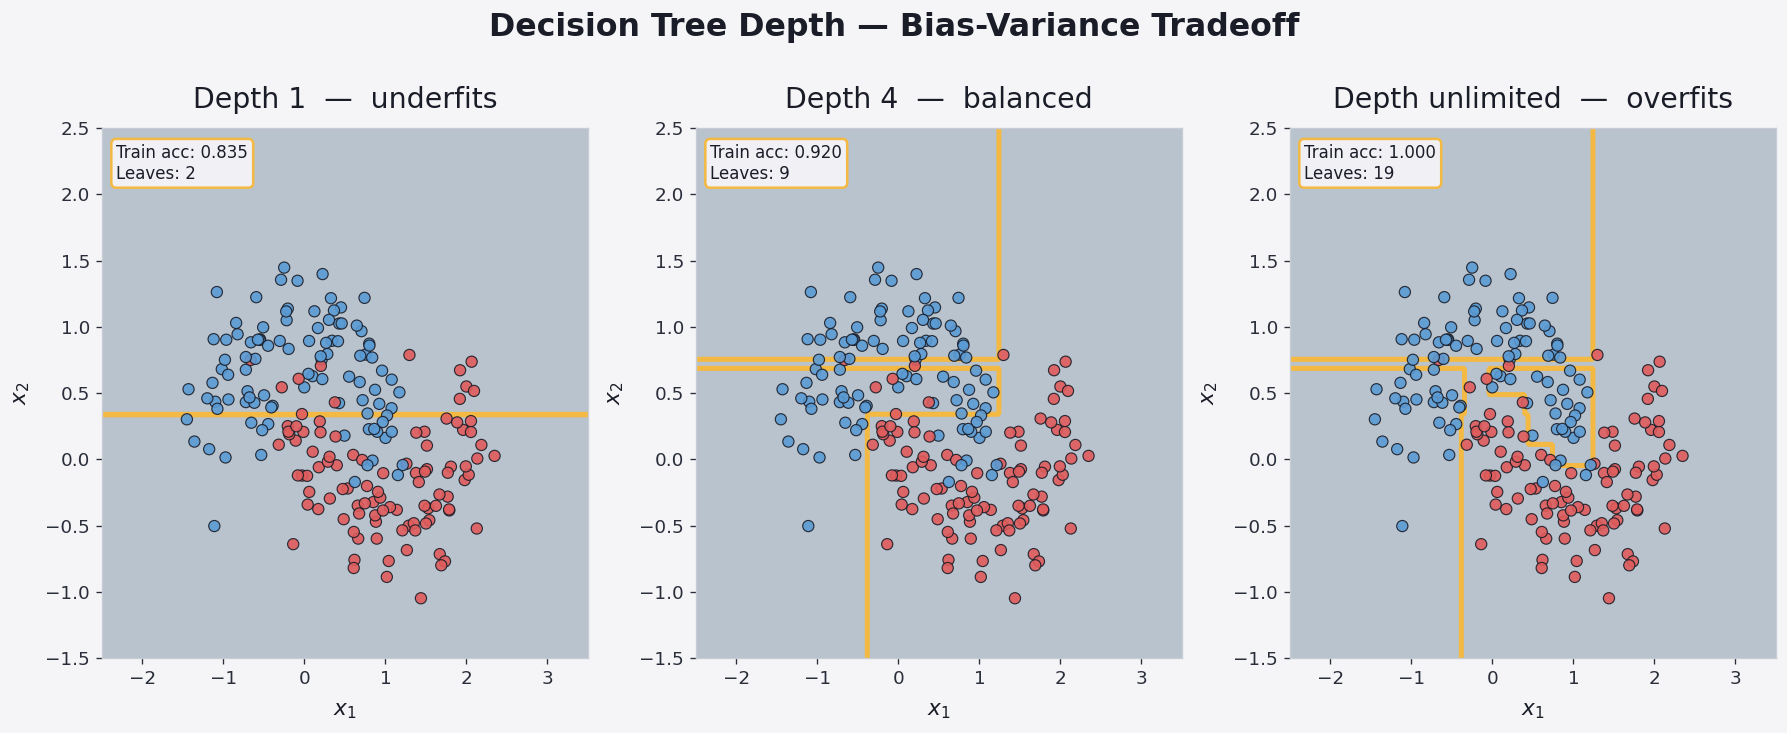

In [4]:
xx, yy = np.meshgrid(np.linspace(-2.5, 3.5, 300),
                     np.linspace(-1.5, 2.5, 300))

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, depth, title in zip(axes,
    [1, 4, None],
    ['Depth 1  —  underfits', 'Depth 4  —  balanced', 'Depth unlimited  —  overfits']):

    clf = DecisionTreeClassifier(max_depth=depth, random_state=0)
    clf.fit(X2, y2)
    ZZ = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, ZZ, alpha=0.3,
                colors=['#1a3a5c', '#5c1a1a'])
    ax.contour(xx, yy, ZZ, colors=CB, linewidths=2)
    ax.scatter(X2[:,0], X2[:,1],
               c=[C1 if yi else C0 for yi in y2],
               s=45, edgecolors='#1a1d27', lw=0.7, alpha=0.9, zorder=4)

    tr_acc = accuracy_score(y2, clf.predict(X2))
    ax.set_xlabel('$x_1$', labelpad=8); ax.set_ylabel('$x_2$', labelpad=8)
    ax.set_title(title, pad=12); ax.grid(False)
    ax.text(0.03, 0.97, f'Train acc: {tr_acc:.3f}\nLeaves: {clf.get_n_leaves()}',
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round', fc='#f0f0f5', ec=CB, lw=1.5))

fig.suptitle('Decision Tree Depth — Bias-Variance Tradeoff',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## The Staircase Decision Boundary

Because each split is axis-aligned (one feature at a time), the decision boundary is always a **staircase of horizontal and vertical lines** — no matter how complex the true boundary is.

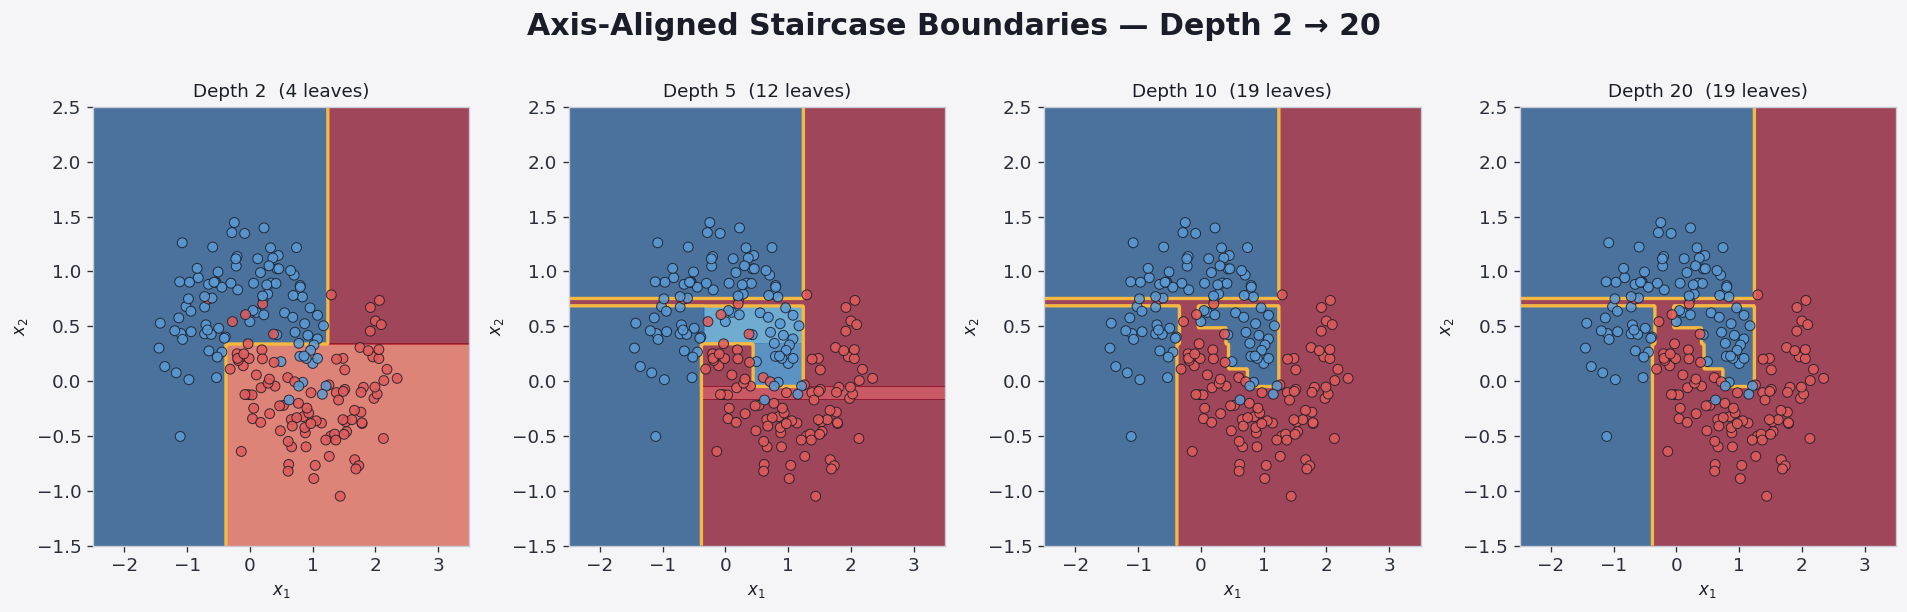

In [5]:
depths = [2, 5, 10, 20]
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, depth in zip(axes, depths):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=0)
    clf.fit(X2, y2)
    ZZ = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

    ax.contourf(xx, yy, ZZ, levels=15, cmap='RdBu_r', alpha=0.75)
    ax.contour(xx, yy, ZZ, levels=[0.5], colors=CB, linewidths=2)
    ax.scatter(X2[:,0], X2[:,1],
               c=[C1 if yi else C0 for yi in y2],
               s=35, edgecolors='#1a1d27', lw=0.6, alpha=0.85, zorder=5)
    ax.set_title(f'Depth {depth}  ({clf.get_n_leaves()} leaves)', fontsize=11)
    ax.set_xlabel('$x_1$', fontsize=10); ax.set_ylabel('$x_2$', fontsize=10)
    ax.grid(False)

fig.suptitle('Axis-Aligned Staircase Boundaries — Depth 2 → 20',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Visual Sweep — Depth & Minimum Leaf Size

Two knobs control tree complexity:

- **`max_depth`** caps how many questions the tree may chain. Small → broad regions; large → splinters.
- **`min_samples_leaf`** forces every leaf to hold at least this many training points. Small → memorises noise; large → smooths the staircase.

The first grid sweeps `max_depth` at six values with `min_samples_leaf=1`. The second grid holds `max_depth=10` and sweeps `min_samples_leaf`. The follow-up bias-variance curve traces train vs test accuracy across depths — where the green (test) line drops while blue (train) keeps climbing, you are firmly in overfitting territory.


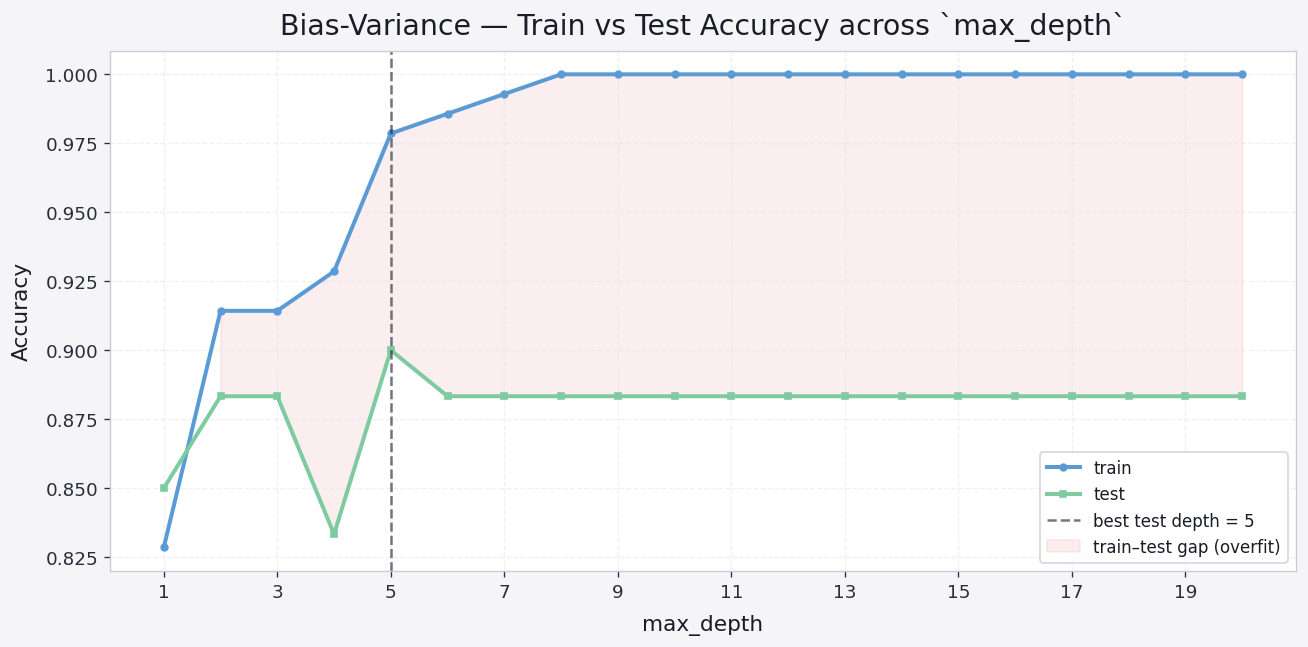

In [6]:
from sklearn.model_selection import train_test_split as _tts2
_X2tr, _X2te, _y2tr, _y2te = _tts2(X2, y2, test_size=0.30, random_state=0, stratify=y2)

# Bias-variance curve — train vs test accuracy across max_depth
_depth_grid = list(range(1, 21))
_tr_curve, _te_curve = [], []
for _d in _depth_grid:
    _c = DecisionTreeClassifier(max_depth=_d, min_samples_leaf=1, random_state=0).fit(_X2tr, _y2tr)
    _tr_curve.append(accuracy_score(_y2tr, _c.predict(_X2tr)))
    _te_curve.append(accuracy_score(_y2te, _c.predict(_X2te)))
_best_idx = int(np.argmax(_te_curve))

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(_depth_grid, _tr_curve, color=C0, lw=2.4, marker='o', ms=4, label='train')
ax.plot(_depth_grid, _te_curve, color=CM, lw=2.4, marker='s', ms=4, label='test')
ax.axvline(_depth_grid[_best_idx], color='#1a1d27', ls='--', lw=1.5, alpha=0.6,
           label=f'best test depth = {_depth_grid[_best_idx]}')
ax.fill_between(_depth_grid, _te_curve, _tr_curve,
                where=np.array(_tr_curve) > np.array(_te_curve),
                color=C1, alpha=0.10, label='train–test gap (overfit)')
ax.set_xlabel('max_depth', labelpad=8)
ax.set_ylabel('Accuracy', labelpad=8)
ax.set_title('Bias-Variance — Train vs Test Accuracy across `max_depth`', pad=10)
ax.set_xticks(_depth_grid[::2])
ax.legend(loc='lower right', fontsize=10); ax.grid(True)
plt.tight_layout(); plt.show()


---
## Feature Importance

Each feature is scored by the **total reduction in impurity** it achieves across all splits in the tree.
Features that split early at the root (affecting many samples) get higher importance.

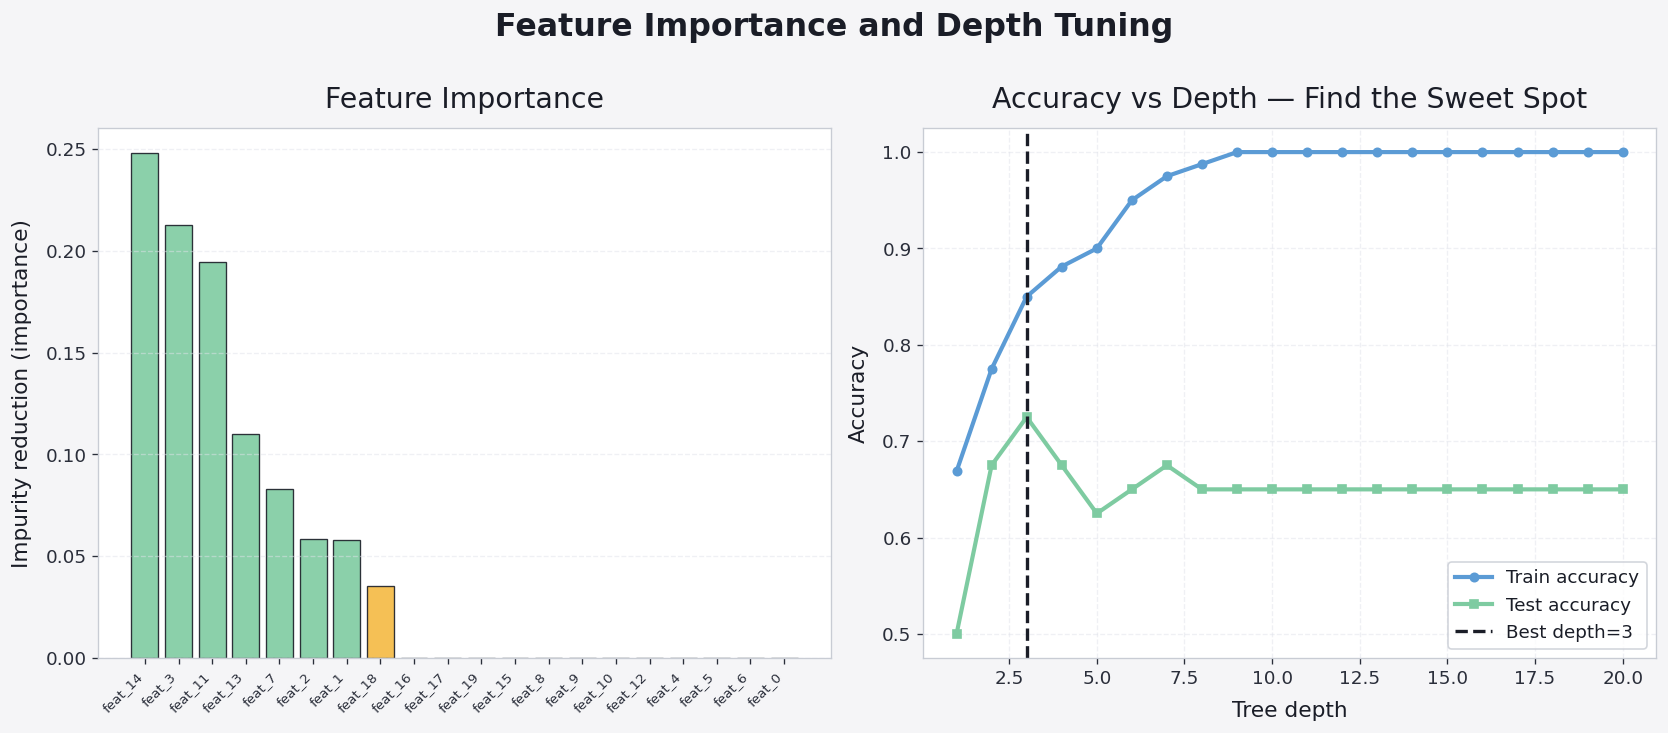

In [7]:
clf_full = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_full.fit(X_tr, y_tr)
importances = clf_full.feature_importances_
sort_idx    = np.argsort(importances)[::-1]
feature_names = [f'feat_{i}' for i in range(X_tr.shape[1])]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: feature importance bar
ax = axes[0]
cols_imp = [CM if importances[i] > 0.05 else CB if importances[i] > 0.02 else '#3a3d60'
            for i in sort_idx]
ax.bar(range(20), importances[sort_idx], color=cols_imp,
       edgecolor='#1a1d27', lw=0.8, alpha=0.9)
ax.set_xticks(range(20))
ax.set_xticklabels([feature_names[i] for i in sort_idx], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Impurity reduction (importance)', labelpad=8)
ax.set_title('Feature Importance', pad=12)
ax.grid(True, axis='y')

# Right: train vs test accuracy vs depth
depth_range = range(1, 21)
train_acc = []
test_acc  = []
for d in depth_range:
    clf_d = DecisionTreeClassifier(max_depth=d, random_state=0)
    clf_d.fit(X_tr, y_tr)
    train_acc.append(accuracy_score(y_tr, clf_d.predict(X_tr)))
    test_acc.append(accuracy_score(y_te, clf_d.predict(X_te)))

ax = axes[1]
ax.plot(list(depth_range), train_acc, color=C0, lw=2.5, marker='o', ms=5, label='Train accuracy')
ax.plot(list(depth_range), test_acc,  color=CM, lw=2.5, marker='s', ms=5, label='Test accuracy')
best_d = list(depth_range)[np.argmax(test_acc)]
ax.axvline(best_d, color='#1a1d27', ls='--', lw=2, label=f'Best depth={best_d}')
ax.set_xlabel('Tree depth', labelpad=8)
ax.set_ylabel('Accuracy', labelpad=8)
ax.set_title('Accuracy vs Depth — Find the Sweet Spot', pad=12)
ax.legend(loc='lower right'); ax.grid(True)

fig.suptitle('Feature Importance and Depth Tuning', fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Confusion Matrix & Metrics

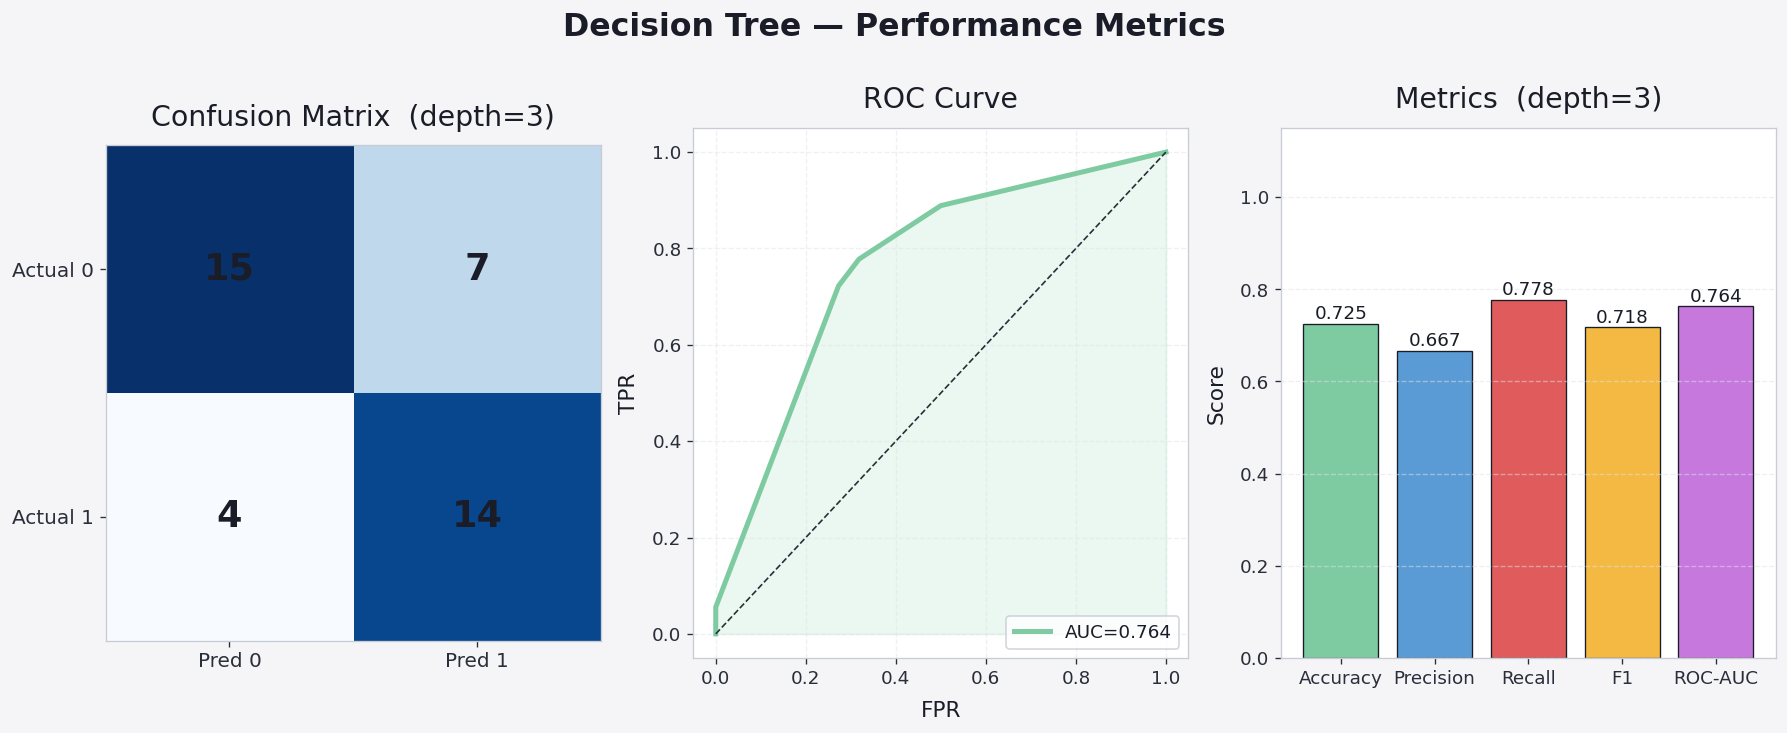

In [8]:
clf_best = DecisionTreeClassifier(max_depth=best_d, random_state=42)
clf_best.fit(X_tr, y_tr)
preds = clf_best.predict(X_te)
probs = clf_best.predict_proba(X_te)[:, 1]
cm    = confusion_matrix(y_te, preds)
fpr, tpr, _ = roc_curve(y_te, probs)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Confusion matrix
ax = axes[0]
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=22, fontweight='bold',
                color='#1a1d27' if cm[i,j]>cm.max()/2 else '#1a1d27')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred 0','Pred 1'], fontsize=12)
ax.set_yticklabels(['Actual 0','Actual 1'], fontsize=12)
ax.set_title(f'Confusion Matrix  (depth={best_d})', pad=12)

# ROC
ax = axes[1]
ax.plot(fpr, tpr, color=CM, lw=3, label=f'AUC={roc_auc:.3f}')
ax.fill_between(fpr, tpr, alpha=0.15, color=CM)
ax.plot([0,1],[0,1], color='#2a2e3a', ls='--', lw=1)
ax.set_xlabel('FPR', labelpad=8); ax.set_ylabel('TPR', labelpad=8)
ax.set_title('ROC Curve', pad=12)
ax.legend(loc='lower right'); ax.grid(True)

# Metrics bar
ax = axes[2]
metrics_vals = {
    'Accuracy':  accuracy_score(y_te, preds),
    'Precision': precision_score(y_te, preds),
    'Recall':    recall_score(y_te, preds),
    'F1':        f1_score(y_te, preds),
    'ROC-AUC':   roc_auc,
}
bars = ax.bar(list(metrics_vals.keys()), list(metrics_vals.values()),
              color=[CM, C0, C1, CB, CP], edgecolor='#1a1d27', lw=0.8)
for bar, val in zip(bars, metrics_vals.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', labelpad=8)
ax.set_title(f'Metrics  (depth={best_d})', pad=12)
ax.grid(True, axis='y')

fig.suptitle('Decision Tree — Performance Metrics', fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Everything on One Canvas

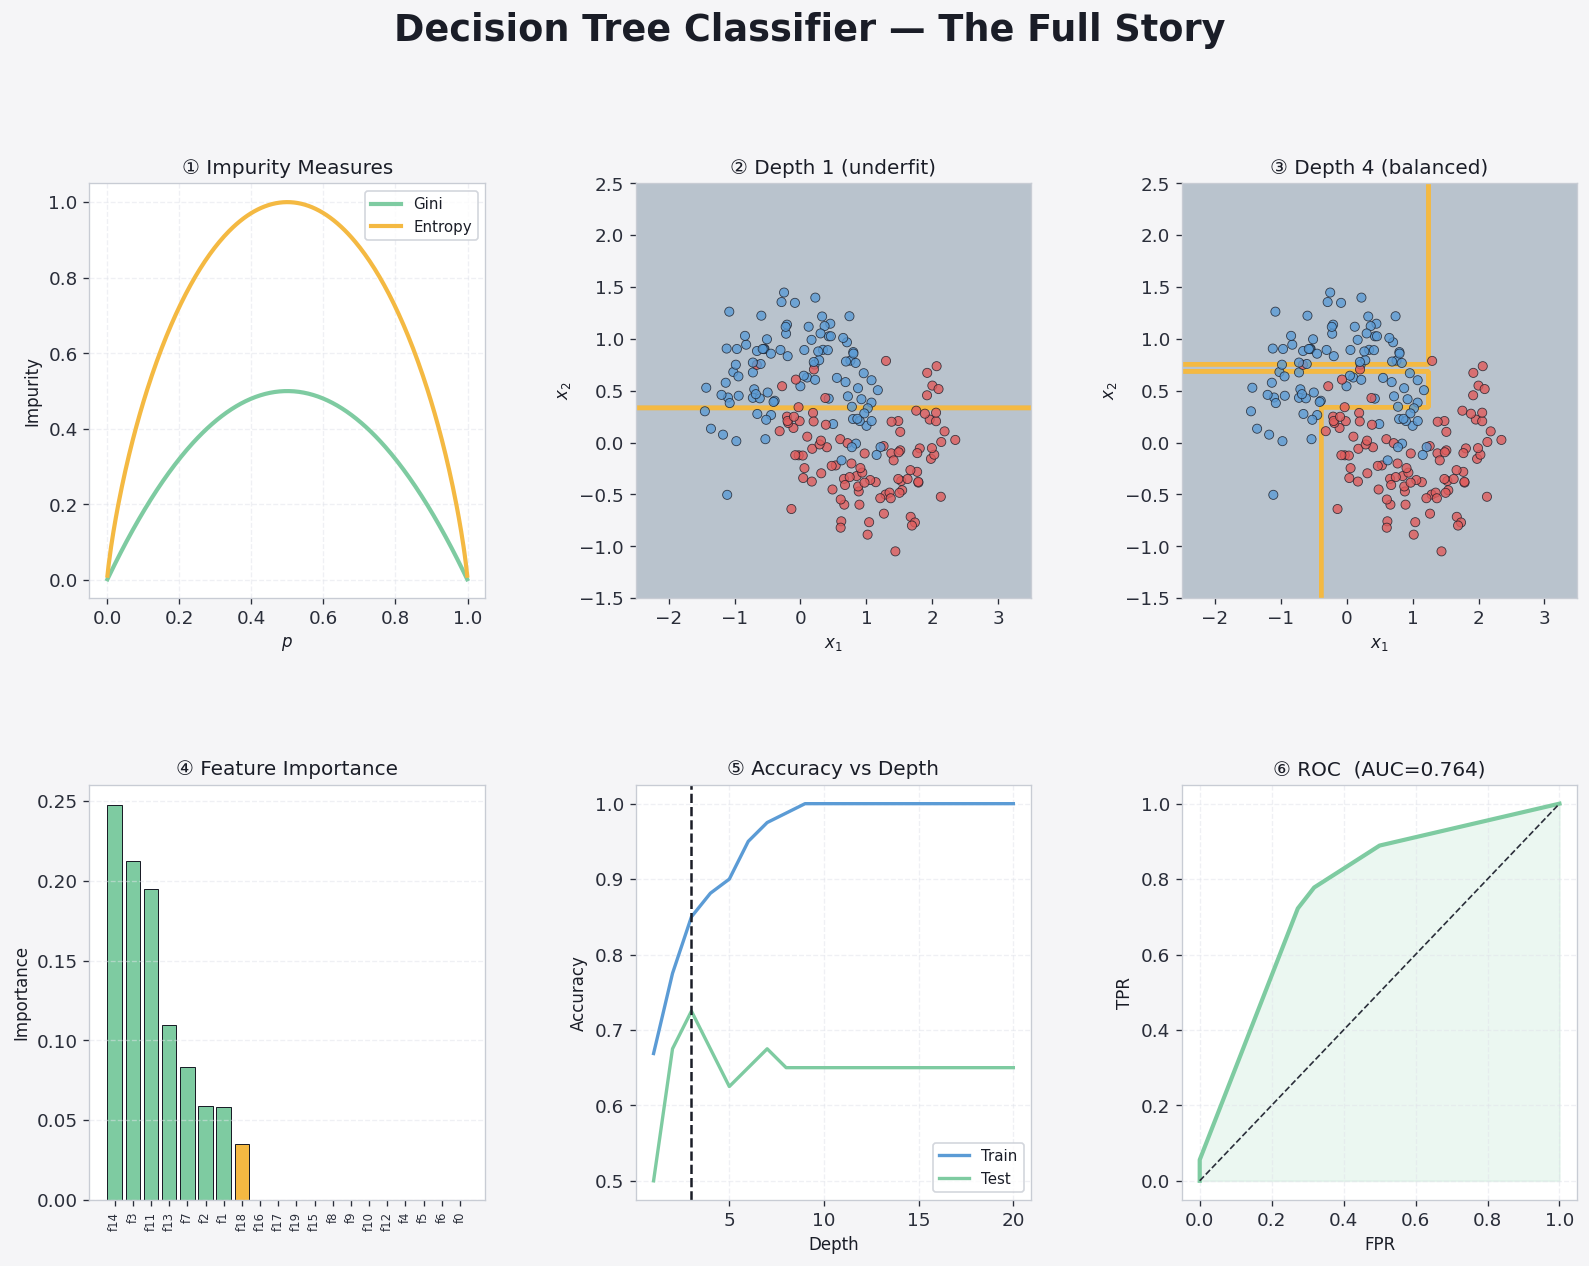

In [9]:
fig = plt.figure(figsize=(16, 11), facecolor='#f5f5f7')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# (0,0) Impurity
ax = fig.add_subplot(gs[0, 0])
ax.plot(p, gini, color=CM, lw=2.5, label='Gini')
ax.plot(p, entropy, color=CB, lw=2.5, label='Entropy')
ax.set_title('① Impurity Measures', fontsize=12)
ax.set_xlabel('$p$', fontsize=10); ax.set_ylabel('Impurity', fontsize=10)
ax.legend(fontsize=9); ax.grid(True)

# (0,1) Depth 1
ax = fig.add_subplot(gs[0, 1])
clf1 = DecisionTreeClassifier(max_depth=1, random_state=0)
clf1.fit(X2, y2)
ZZ1 = clf1.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, ZZ1, alpha=0.3, colors=['#1a3a5c','#5c1a1a'])
ax.contour(xx, yy, ZZ1, colors=CB, linewidths=2)
ax.scatter(X2[:,0], X2[:,1], c=[C1 if yi else C0 for yi in y2],
           s=30, edgecolors='#1a1d27', lw=0.5, alpha=0.8, zorder=4)
ax.set_title('② Depth 1 (underfit)', fontsize=12)
ax.set_xlabel('$x_1$', fontsize=10); ax.set_ylabel('$x_2$', fontsize=10)

# (0,2) Depth 4
ax = fig.add_subplot(gs[0, 2])
clf4 = DecisionTreeClassifier(max_depth=4, random_state=0)
clf4.fit(X2, y2)
ZZ4 = clf4.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, ZZ4, alpha=0.3, colors=['#1a3a5c','#5c1a1a'])
ax.contour(xx, yy, ZZ4, colors=CB, linewidths=2)
ax.scatter(X2[:,0], X2[:,1], c=[C1 if yi else C0 for yi in y2],
           s=30, edgecolors='#1a1d27', lw=0.5, alpha=0.8, zorder=4)
ax.set_title('③ Depth 4 (balanced)', fontsize=12)
ax.set_xlabel('$x_1$', fontsize=10); ax.set_ylabel('$x_2$', fontsize=10)

# (1,0) Feature importance
ax = fig.add_subplot(gs[1, 0])
ax.bar(range(20), importances[sort_idx], color=cols_imp, edgecolor='#1a1d27', lw=0.6)
ax.set_xticks(range(20))
ax.set_xticklabels([f'f{i}' for i in sort_idx], rotation=90, fontsize=7)
ax.set_title('④ Feature Importance', fontsize=12)
ax.set_ylabel('Importance', fontsize=10)
ax.grid(True, axis='y')

# (1,1) Accuracy vs depth
ax = fig.add_subplot(gs[1, 1])
ax.plot(list(depth_range), train_acc, color=C0, lw=2, label='Train')
ax.plot(list(depth_range), test_acc,  color=CM, lw=2, label='Test')
ax.axvline(best_d, color='#1a1d27', ls='--', lw=1.5)
ax.set_title('⑤ Accuracy vs Depth', fontsize=12)
ax.set_xlabel('Depth', fontsize=10); ax.set_ylabel('Accuracy', fontsize=10)
ax.legend(fontsize=9); ax.grid(True)

# (1,2) ROC
ax = fig.add_subplot(gs[1, 2])
ax.plot(fpr, tpr, color=CM, lw=2.5)
ax.fill_between(fpr, tpr, alpha=0.15, color=CM)
ax.plot([0,1],[0,1], color='#2a2e3a', ls='--', lw=1)
ax.set_title(f'⑥ ROC  (AUC={roc_auc:.3f})', fontsize=12)
ax.set_xlabel('FPR', fontsize=10); ax.set_ylabel('TPR', fontsize=10)
ax.grid(True)

fig.suptitle('Decision Tree Classifier — The Full Story',
             fontsize=22, fontweight='bold', color='#1a1d27', y=1.01)
plt.show()

---
## ⚖️ When to use a single tree — and when not to

| Situation | Single Tree | Random Forest | GBM | Linear |
|---|---|---|---|---|
| Need a human-readable rule | ✅ | ❌ | ❌ | ✅ |
| Best raw accuracy | ❌ overfits | ✅ | ✅ | partial |
| Mixed numerical + categorical | ✅ | ✅ | ✅ | ❌ encode |
| Small data, low signal | ❌ unstable | partial | partial | ✅ |

> A single tree is a **diagnostic tool** more than a production model — use it for explanation, then ensemble for accuracy.


---
## 🎯 Try this

1. **Depth vs error.** Sweep `max_depth` from 1 to 20 and plot train + test error. Watch the classic U: bias dominates left, variance dominates right.
2. **Cost-complexity pruning.** Use `ccp_alpha` to prune. The simplest tree within 1-SE of the best is usually a great compromise.
3. **Surrogate splits.** With missing data, examine which features substitute for each other at top splits — this is one place trees beat linear models out of the box.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Splitting criterion | Gini impurity or Entropy | Choose the split that most reduces impurity |
| Gini impurity | $G = 1 - \sum_k p_k^2$ | 0 = pure node; 0.5 = maximally mixed (binary) |
| Entropy | $H = -\sum_k p_k \log_2 p_k$ | 0 = pure; 1 = maximally mixed (binary) |
| max_depth | Maximum levels of splits | Key regularisation parameter — tune by CV |
| Decision boundary | Axis-aligned staircase | Cannot learn diagonal or curved boundaries directly |
| Feature importance | Total impurity decrease per feature | Features used near the root get highest importance |
| Overfitting | Deep tree → 1 sample per leaf → 100% train acc | Use `max_depth`, `min_samples_leaf` to prevent |

**Key insight:** a Decision Tree is highly interpretable — you can follow the splits from root to leaf to understand any prediction. But a single tree has high variance; use Random Forest or Gradient Boosting to tame it.